<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex2_LIF/TNS_I_Exercise_2_lif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leaky Integrate \& Fire Neuron

The leaky integrate \& fire model (LIF model) of a neuron adds two new elements to the single-compartment model (SCM) of a cell: a reversal potential and a spiking threshold.

## State variables and parameters

A neuron is modelled as a membrane-enclosed volume, with membrane resistance $r_m$, capacitance $c_m$, and time-constant $\tau_m$:  

\\
$$
r_m = 1.5\,M\Omega mm^2,\qquad\qquad c_m = 20\,nF/mm^2,\qquad\qquad \tau_m = r_m \, c_m = 30\,\mathit{ms}
$$

\\

Its state at time $t$ is given by membrane potential $V_m(t)$ and input current $i_e(t)$.  

Additional model parameters are the reversal potential $E_L$, reset potential $V_{reset}$, and spiking threshold $V_{thresh}$:
$$
E_L = V_{reset} = -65 \, mV, \qquad\qquad V_{thresh} = -50 \, mV
$$


The initial condition is
$$
V_0 = V_m(t=0) = -65 \, mV
$$


## Dynamical equation

The membrane potential changes over time according to the dynamic equation

\\

$$
\frac{dV_m(t)}{dt} = \frac{1}{\tau_m} \left[ r_m \cdot i_e(t) + E_L - V_m(t) \right]
$$

\\

provided the membrane potential remains below threshold, $V_m(t) < V_{thresh}$.   

\\

When $V_m(t) \geq  V_{thresh}$, $V_m(t)$ is instantaneously reset to $V_{reset}$ whenever.

\\

Note that this mechanism requires that the threshold is higher than the reset potential:
$$
V_{th}>E_L\geq V_{reset}
$$


## Numerical integration

We do not use the Euler discretisation, but solve the dynamical equation analytically for small time intervals $\Delta t$, assuming that $i_e(t)$ remains constant over this time.

\\

$$
V_m(t+\Delta t)  =  V_m(t) \, \exp\left(-\frac{\Delta t}{\tau_m} \right) +  \left[i_e(t) \cdot r_m + E_L\right] \, \left[ 1 - \exp\left(-\frac{\Delta t}{\tau_m} \right) \right]
$$

\\

This rule holds as long as $V_m(t+\Delta t)$ remains below $V_{thresh}$.  Whenever it reaches or exceeds this value we reset according to

\\

$$
V_m(t+\Delta t) = V_{reset}
$$

## Assignments

You are provided with some starting code below which you should build up and modify. Starting from this, please carry out the following steps:

1. Define parameters.
2. Define an appropriate time vector, ranging from $0\,ms$ to $T=500\,ms$ in steps of $\Delta t = 0.1\, ms$.
3. Define a constant input current $i_0 = 12\,nA/mm^2$ for all $t$.
4. Plot the input current against time (first axis).
5. Iteratively compute the membrane potential $V_m$.   Don't forget the spiking mechanism!
6. Plot the membrane voltage against time (second axis). Combine several plots in one figure.
7. Add code to store the times of any spikes  (when $V(t+\Delta t)$ was reset) in a vector $t_{spike}$.
8. Compute yet another vector, now with the inter-spike-intervals $t_{isi}$. You can do this very easily by calling *np.diff()*
9. Compute the mean interspike interval.

\\

You can now investigate the effects of other input currents.
1. Simulate the membrane potential for a sinusoidal current of low frequency:

$$
i_e(t) = i_0\cdot \sin(2\pi f \,t), \quad f = 4\,Hz
$$
2. Simulate the membrane potential for a sinusoidal current of medium frequency:

$$
i_e(t) = i_0\cdot \sin(2\pi f \,t), \quad f = 20\,Hz
$$
3. Simulate the membrane potential for a ramping current:

$$
i_e(t) = i_0 \cdot t / 150 \, ms
$$



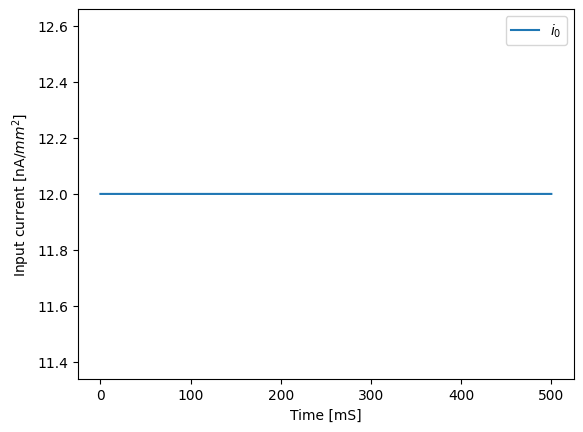

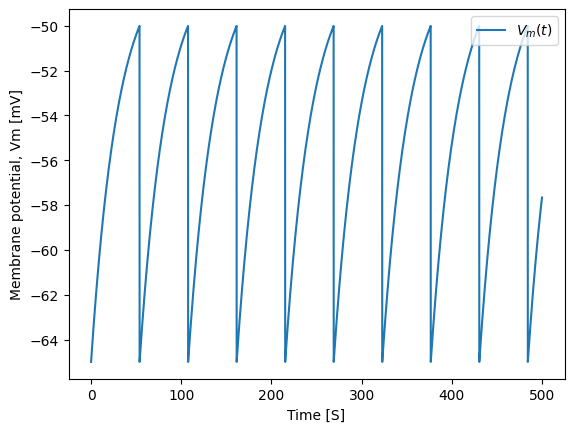

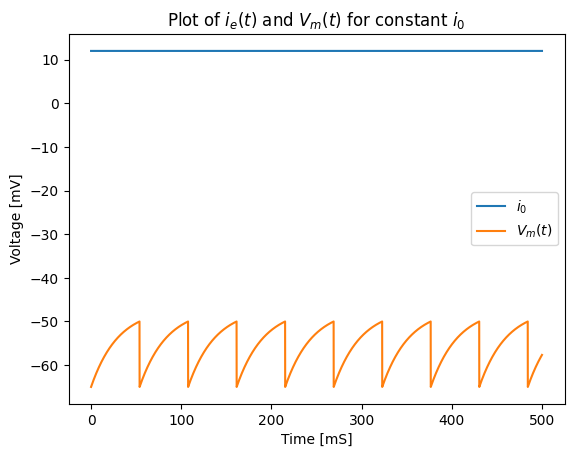

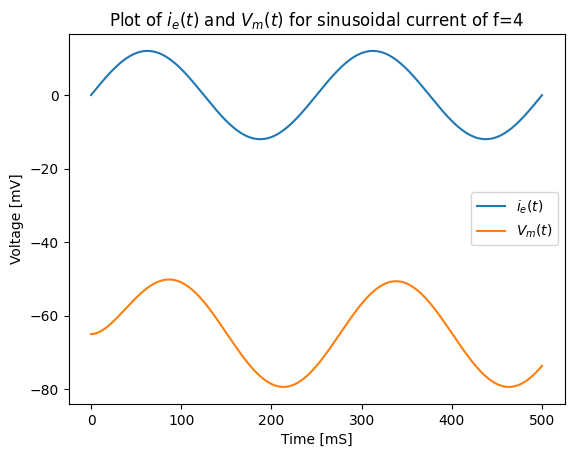

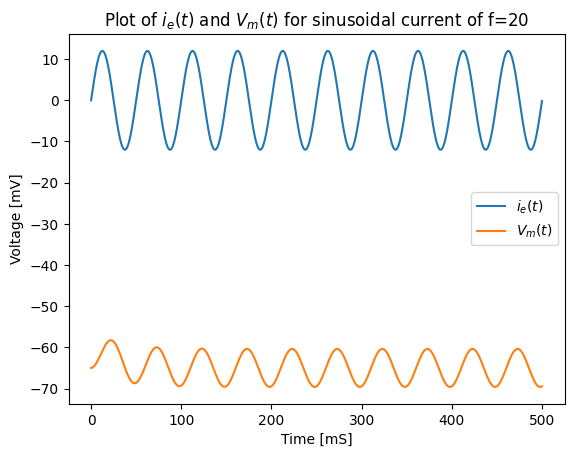

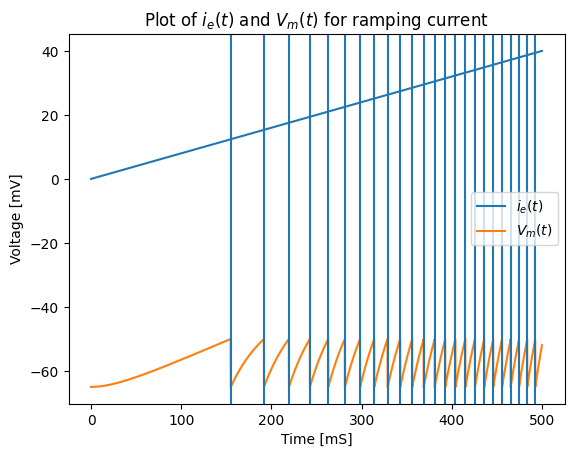

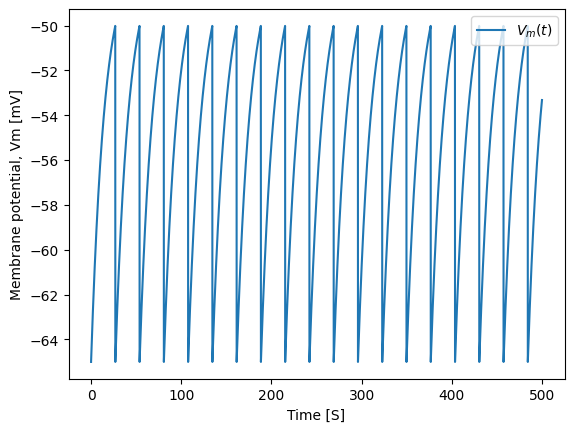

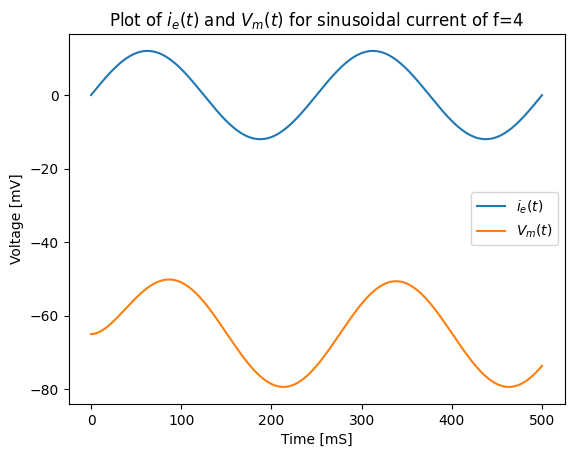

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Define parameters
V_th = -50
EL = -65 # EL, leaky reversal potential
# 3. Define constant input current iZero = 12
iZero = 12 # constant input current, in nA/mm^2
rm = 1.5 # membrane resistance, in Mohm*mm^2
cm = 20 # membrane capacitance, in nF/mm^2
taum = rm*cm # time constant, calculated as the product of membrane resistance and capacitance

T = 0 # starting point for time vector, in mS
Tend = 500 # end point for time vector, in mS
deltaT = 0.1 # size of time steps, in mS

reset_steps = []  # empty list to hold the steps when V is reset to -65
# 2. Define a time vector
timeVector = [] # list of timepoints
while T <= Tend:
  timeVector.append(T)
  T += deltaT

#%% plot constant input current against time

# 4. Plot input current against time
currentVector = []
for t in timeVector:
  currentVector.append(iZero)

'''
note that many of the following labels and titles use some form of $...$, this is LaTeX
formatting and allows the inclusion of subscripts, superscripts, and other math symbols
'''
plt.figure()
plt.plot(timeVector, currentVector, label='$i_0$')
plt.xlabel('Time [mS]')
plt.ylabel('Input current [nA/$mm^2$]')
plt.legend(loc='upper right')
plt.show()
#%% iteratively compute the membrane potential
# 5. compute membrane potential
# set the initial membrane potential to -65, the reversal potential
Vmt = -65
V = []  # voltage vector
tSpikes = []
for actT in range(len(timeVector)):
    V.append(Vmt)
    Vmt = Vmt * np.exp(-(deltaT/taum)) + ((iZero * rm) + EL)*(1 - np.exp(-(deltaT/taum)))
    if Vmt >= V_th:
        Vmt = -65
        # 7. add vector to capture timepoint of spikes
        tSpikes.append(timeVector[actT])

# 6. plot the membrane potential against time
plt.plot(timeVector,V, label='$V_m (t)$')
# if you want to add lines at spike points, uncomment below
'''
# use vector of spike times to add spike lines
for i in tSpikes:
    plt.axvline(i)
'''
plt.xlabel('Time [S]')
plt.ylabel('Membrane potential, Vm [mV]')
plt.legend(loc='upper right')
plt.show()

# 8. calculate inter-spike-interval
isi = np.diff(tSpikes)
# 9. calculate mean inter-spike-interval
mIsi = np.mean(isi)

#%% plot multiple plots in one figure
plt.close('all')
plt.figure()
plt.plot(timeVector, currentVector, label='$i_0$')
plt.plot(timeVector,V, label='$V_m (t)$')
plt.xlabel('Time [mS]')
plt.ylabel('Voltage [mV]')
plt.legend(loc='center right')
plt.title('Plot of $i_e (t)$ and $V_m (t)$ for constant $i_0$')
plt.show()

#%% plot sinusoidal current of low frequency
ietLowFreqVector = []
V_th = -50
f = 4 # Hz
VmtLowFreq = -65
VmtLowFreqVector = []  # voltage vector
tSpikesLowFreq = []
for t in timeVector:
  # need to account for the timepoints being in mS, while Hz is 1/s
  # Ie(t) is the inward current at a given time
  ietLowFreq = iZero * np.sin(2*np.pi*f*(t/1000))
  ietLowFreqVector.append(ietLowFreq)
  VmtLowFreq = VmtLowFreq * np.exp(-(deltaT/taum)) + ((ietLowFreq * rm) + EL)*(1 - np.exp(-(deltaT/taum)))
  VmtLowFreqVector.append(VmtLowFreq)
  if VmtLowFreq >= V_th:
      VmtLowFreq = -65
      tSpikesLowFreq.append(t)

plt.figure()
plt.plot(timeVector, ietLowFreqVector, label='$i_e (t)$')
plt.plot(timeVector, VmtLowFreqVector, label='$V_m (t)$')
plt.xlabel('Time [mS]')
plt.ylabel('Voltage [mV]')
plt.legend(loc='center right')
plt.title(f'Plot of $i_e (t)$ and $V_m (t)$ for sinusoidal current of f={f}')
plt.show()
for i in tSpikesLowFreq:
  plt.axvline(i, ymin=-70, ymax=10)

#%% plot sinusoidal current of medium frequency
# EL = -55
ietMedFreqVector = []
f = 20 # Hz
VmtMedFreq = -65
VmtMedFreqVector = []  # voltage vector
tSpikesMedFreq = []
ietMedFreq = iZero
for t in timeVector:
    # need to account for the timepoints being in mS, while Hz is 1/s
  ietMedFreq = iZero * np.sin(2*np.pi*f*(t/1000))
  ietMedFreqVector.append(ietMedFreq)
  VmtMedFreq = VmtMedFreq * np.exp(-(deltaT/taum)) + ((ietMedFreq * rm) + EL)*(1 - np.exp(-(deltaT/taum)))
  VmtMedFreqVector.append(VmtMedFreq)
  if VmtMedFreq >= V_th:
      VmtMedFreq = -65
      tSpikesMedFreq.append(t)
plt.figure()
plt.plot(timeVector, ietMedFreqVector, label='$i_e (t)$')
plt.plot(timeVector, VmtMedFreqVector, label='$V_m (t)$')
plt.xlabel('Time [mS]')
plt.ylabel('Voltage [mV]')
plt.legend(loc='center right')
plt.title(f'Plot of $i_e (t)$ and $V_m (t)$ for sinusoidal current of f={f}')
plt.show()
#%% for ramping current
# EL = -65
ietRampVector = []
VmtRamp = EL
VmtRampVector = []  # voltage vector
tSpikesRamp = []
ietRamp = iZero
for t in timeVector:
    # need to account for the timepoints being in mS, while Hz is 1/s
  ietRamp = iZero * t/150
  ietRampVector.append(ietRamp)
  VmtRampVector.append(VmtRamp)
  VmtRamp = VmtRamp * np.exp(-(deltaT/taum)) + ((ietRamp * rm) + EL)*(1 - np.exp(-(deltaT/taum)))
  if VmtRamp >= V_th:
      VmtRamp = -65
      tSpikesRamp.append(t)

# calculate inter-spike-interval
isiRamp = np.diff(tSpikesRamp)
# 9. calculate mean inter-spike-interval
mIsiRamp = np.mean(isiRamp)
plt.figure()
plt.plot(timeVector, ietRampVector, label='$i_e (t)$')
plt.plot(timeVector, VmtRampVector, label='$V_m (t)$')
plt.xlabel('Time [mS]')
plt.ylabel('Voltage [mV]')
plt.legend(loc='center right')
plt.title('Plot of $i_e (t)$ and $V_m (t)$ for ramping current')
for i in tSpikesRamp:
  plt.axvline(i, ymin=-70, ymax=10)
plt.show()
#%%
def calculateMembranePotential(Vmt, iet=12, deltaT=0.1, rm=1.5, cm=20, EL=-65):
    taum = rm*cm
    VmtPlusT = Vmt * np.exp(-(deltaT/taum)) + ((iet * rm) + EL)*(1 - np.exp(-(deltaT/taum)))
    return VmtPlusT
Vmt = -65
V = []  # voltage vector
tSpikes = []
for actT in range(len(timeVector)):
    V.append(Vmt)
    Vmt = calculateMembranePotential(Vmt, cm=10)
    if Vmt >= V_th:
        Vmt = -65
        # 7. add vector to capture timepoint of spikes
        tSpikes.append(timeVector[actT])

# 6. plot the membrane potential against time
plt.plot(timeVector,V, label='$V_m (t)$')
# if you want to add lines at spike points, uncomment below
'''
# use vector of spike times to add spike lines
for i in tSpikes:
    plt.axvline(i)
'''
plt.xlabel('Time [S]')
plt.ylabel('Membrane potential, Vm [mV]')
plt.legend(loc='upper right')
plt.show()

#%% plot sinusoidal current of low frequency
ietLowFreqVector = []
V_th = -50
f = 4 # Hz
VmtLowFreq = -65
VmtLowFreqVector = []  # voltage vector
tSpikesLowFreq = []
for t in timeVector:
    # need to account for the timepoints being in mS, while Hz is 1/s
  ietLowFreq = iZero * np.sin(2*np.pi*f*(t/1000))
  ietLowFreqVector.append(ietLowFreq)
  VmtLowFreq = calculateMembranePotential(VmtLowFreq, ietLowFreq)
  VmtLowFreqVector.append(VmtLowFreq)
  if VmtLowFreq >= V_th:
      VmtLowFreq = -65
      tSpikesLowFreq.append(t)

plt.figure()
plt.plot(timeVector, ietLowFreqVector, label='$i_e (t)$')
plt.plot(timeVector, VmtLowFreqVector, label='$V_m (t)$')
plt.xlabel('Time [mS]')
plt.ylabel('Voltage [mV]')
plt.legend(loc='center right')
plt.title(f'Plot of $i_e (t)$ and $V_m (t)$ for sinusoidal current of f={f}')
plt.show()
